In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import p_lithostatic, T_geothermal, MagmaChamber, GlobalSystem, GlobalSystemThreshold

In [ ]:
# Random distribution seed
np.random.seed(0)

In [26]:
def run_simulation(props):
  t_b = props["t_b"]
  t_d = props["t_d"]
  K_crust = props["K_crust"]
  G_crust = props["G_crust"]
  K_f = props["K_f"]
  rho0 = props["rho0"]
  mu0 = props["mu0"]
  r_hydr = props["r_hydr"]

  # Fix total volume
  # total_vol = (4/3)*np.pi*1000.0**3
  # Fix mass injection
  # mass_inj = total_vol * rho0 * 0.001

  # Network parameters
  N_chamber = 10
  x_scale = 10000.0
  y_scale = 0.0
  z_scale = 40000.0 # Depth

  # Set limits of characteristic size of chamber
  R_min = 500
  R_max = 500
  # Uniformly randomly distribution volume
  V_min = (4/3)*np.pi*R_min**3
  V_max = (4/3)*np.pi*R_max**3

  # List generation of chamber characteristics
  x_nodes = 0.0 * np.random.rand(N_chamber)
  y_nodes = 0.0 * np.random.rand(N_chamber)
  z_nodes = np.linspace(0.0, z_scale, N_chamber)
  V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

  # Symmetric distance matrix
  d = np.sqrt((x_nodes - x_nodes[:,np.newaxis]) ** 2
      + (y_nodes - y_nodes[:,np.newaxis]) ** 2
      + (z_nodes - z_nodes[:,np.newaxis]) ** 2)

  list_nodes = [MagmaChamber(
                      x=x,
                      y=y,
                      z=z,
                      p_setting=None,
                      T_setting=1200,
                      V_setting=V)
                for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]
  
  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=1e3,
                                    dpdx_threshold_scale=0.0,#1e2,
                                    R_outer_ratio=20,)

  q0 = global_sys.q0

  # Compute initial L, M(q0), f
  L, M, f = global_sys.assemble_global_LMf(q0)

  # Time vector
  N_t:int=7500
  t_vec = None
  if t_vec is None:
    t1 = 15e10
    t_vec = np.linspace(0, t1, N_t)
  
  # Set mass rate for injection
  mdot_inj = 3.0
  # Add source term for injection
  f_inj = 0.0 * f
  f_inj[global_sys.data_slice_global(0, "mass")] = mdot_inj

  # Eruption parameters
  r_conduit = 25
  mu_erupt = 1e5
  # Overpressure required for eruption
  p_erupt = 5e6

  ''' Timestepping '''

  # Start q with initial condition
  q = q0.copy()
  # Allocate full output storage
  q_out = np.zeros((t_vec.size, *q.shape))
  # Save last dt for cache check
  dt = np.nan
  dt_last = np.nan
  dt_last_last = np.nan
  # Max order possible
  max_order = np.ones(t_vec.size, dtype=int)

  global_sys._step_strategy = np.zeros(t_vec.size, dtype=float)
  L, M, f = global_sys.assemble_global_LMf(q)
  # lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + 0.5 * dt * L)

  m_erupted = 0.0
  m_erupted_out = np.zeros((t_vec.size,))

  for i, t in enumerate(t_vec):
    if i > 0:
      # Compute timestep
      dt = t_vec[i] - t_vec[i-1]

      M = global_sys.assemble_global_LMf(q, skip_Lf=True)

      # Strang split      
      # q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * L, q + f * dt)

      p_node = global_sys.pressure(q)
      
      deltap = (p_node[-1] - global_sys.nodes[-1].p0) - p_erupt
      f_erupt = 0.0 * f_inj
      if deltap > 0:
        eruption_rate = global_sys.rho0 * (deltap / (16.0 * mu_erupt)) * r_conduit * r_conduit * r_conduit
        # Eruption rate limiter for first-order Euler
        # Volatile-free estimate for pressure-equilibrium mass
        # Assumes hysteresis (empties down to zero overpressure)
        # This is a key parameter for inter-eruption time
        V0 = 4*np.pi*global_sys.nodes[-1].R0**3/3
        dV = global_sys.u(q)[-1,0] * (4 * np.pi * global_sys.nodes[-1].R0**2)
        max_eruption_rate = (q[global_sys.data_slice_global(-1, "mass")] - (V0 + dV) / V0 * global_sys.nodes[-1].m0) / dt
        if eruption_rate > max_eruption_rate:
          eruption_rate = max_eruption_rate
        # Set eruption rate in mass conservation equation
        f_erupt[global_sys.data_slice_global(-1, "mass")] = -eruption_rate
        
        # Integrate erupted mass
        m_erupted += eruption_rate * dt

      # Quasi-implicit one-step solve (strictly M(q^n) is used instead of M(q^n+1))
      q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * (L + M), q + dt * (f + f_inj + f_erupt))[:,np.newaxis]

    dt_last_last = dt_last
    dt_last = dt
    q = np.reshape(q, (q.size, 1))
    # Save result
    q_out[i,...] = q
    m_erupted_out[i] = m_erupted

  # Post-process with output size (n_t, n_chambers, (N_r))
  m, p, sigmas, u = global_sys.post_process(t_vec, q_out)

  return z_scale, q_out, global_sys, m, m_erupted_out, t_vec, p, sigmas, u


In [32]:
# # Example prop dict
# props = dict(
#   t_b = 1e11,     # Set Maxwell times
#   t_d = 5e10,     # Set Maxwell times
#   K_crust = 10e9,
#   G_crust = 10e9,
#   K_f = 10e9,
#   rho0 = 2500,
#   mu0 = 1e6,      # Constant viscosity assumption
#   r_hydr = 5,     # Effective hydraulic radius
# )

def prop_factory(t_b=1e11, t_d=5e10, K_crust=10e9, G_crust=10e9,
                 K_f=10e9, rho0=2500, mu0=1e6, r_hydr=5):
  return dict(
    t_b = t_b,     # Set Maxwell times
    t_d = t_d,     # Set Maxwell times
    K_crust = K_crust,
    G_crust = G_crust,
    K_f = K_f,
    rho0 = rho0,
    mu0 = mu0,      # Constant viscosity assumption
    r_hydr = r_hydr,     # Effective hydraulic radius
  )

tup1 = run_simulation(prop_factory(t_b=1e13, t_d=100e9))
tup2 = run_simulation(prop_factory(t_b=10e9, t_d=100e9))
tup3 = run_simulation(prop_factory(t_b=100e9, t_d=100e9))
tup4 = run_simulation(prop_factory(t_b=1000e9, t_d=100e9))
tup5 = run_simulation(prop_factory(t_b=1000e9, t_d=1000e9))
tup6 = run_simulation(prop_factory(t_b=10e9, t_d=10e9))

# Unpack tup
# z_scale, q_out, global_sys, m, m_erupted_out, t_vec, p, sigmas, u = solution_tup

In [44]:
tup2[5]

array([0.00000000e+00, 2.00026670e+07, 4.00053340e+07, ...,
       1.49959995e+11, 1.49979997e+11, 1.50000000e+11])

Maxwell time $t_d = 100 \times 10^{9} s$


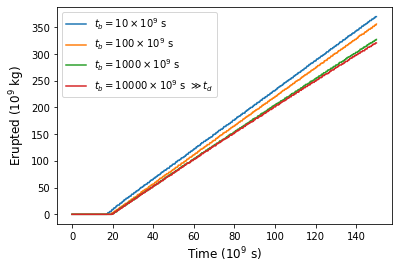

In [43]:
m_plot_scale = 1e9
t_plot_scale = 1e9
plt.plot(tup2[5]/t_plot_scale, tup2[4]/m_plot_scale, label=r"$t_b = 10 \times 10^{9}$ s")
plt.plot(tup3[5]/t_plot_scale, tup3[4]/m_plot_scale, label=r"$t_b = 100 \times 10^{9}$ s")
plt.plot(tup4[5]/t_plot_scale, tup4[4]/m_plot_scale, label=r"$t_b = 1000 \times 10^{9}$ s")
plt.plot(tup1[5]/t_plot_scale, tup1[4]/m_plot_scale, label=r"$t_b = 10 000 \times 10^{9}$ s $\gg t_d$")
# plt.plot(tup5[5], tup5[4])
# plt.plot(tup6[5], tup6[4])
# ax[1].plot(t_vec/t_plot_scale, m_erupted_out/m_plot_scale, 'k')
plt.xlabel("Time ($10^9$ s)", fontsize=12)
plt.ylabel("Erupted ($10^9$ kg)", fontsize=12)
# plt.xlim(t_vec[0]/1e9, t_vec[-1]/1e9)

plt.legend()
print(r"Maxwell time $t_d = 100 \times 10^{9} s$")


In [ ]:
tup7 = run_simulation(prop_factory(t_b=1e9, t_d=1e9))
tup8 = run_simulation(prop_factory(t_b=.1e9, t_d=.1e9))

In [ ]:
tup9 = run_simulation(prop_factory(t_b=30e9, t_d=30e9))

$t_b = t_d$


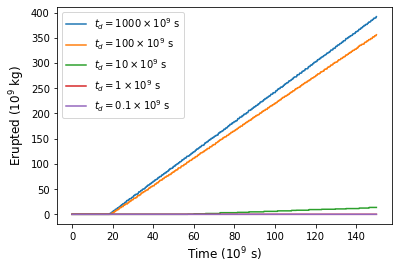

In [ ]:
plt.plot(tup5[5]/t_plot_scale, tup5[4]/m_plot_scale, label=r"$t_d = 1000 \times 10^{9}$ s")
plt.plot(tup3[5]/t_plot_scale, tup3[4]/m_plot_scale, label=r"$t_d = 100 \times 10^{9}$ s")
plt.plot(tup9[5]/t_plot_scale, tup9[4]/m_plot_scale, label=r"$t_d = 10 \times 10^{9}$ s")
plt.plot(tup6[5]/t_plot_scale, tup6[4]/m_plot_scale, label=r"$t_d = 10 \times 10^{9}$ s")
plt.plot(tup7[5]/t_plot_scale, tup7[4]/m_plot_scale, label=r"$t_d = 1 \times 10^{9}$ s")
plt.plot(tup8[5]/t_plot_scale, tup8[4]/m_plot_scale, label=r"$t_d = 0.1 \times 10^{9}$ s")
print("$t_b = t_d$")

plt.xlabel("Time ($10^9$ s)", fontsize=12)
plt.ylabel("Erupted ($10^9$ kg)", fontsize=12)
plt.legend()

In [28]:
z_sample_mesh = np.linspace(0, z_scale, 20)
mdot_grid = np.zeros((q_out.shape[0], z_sample_mesh.size))

def eval_mdot_contribution(tup, z):
  ''' Evaluate contribution to mass rate of a particular pairwise flow at location x.
  Input:
    tup: tuple containing (z_0, z_1, and mdot from chamber 0 to chamber 1 )
    z: depth to evaluate at '''
  # Check whether z is between z_0 and z_1
  z_min = 0.5 * (tup[0] + tup[1]) - 0.5 * np.abs(tup[1] - tup[0])
  z_max = 0.5 * (tup[0] + tup[1]) + 0.5 * np.abs(tup[1] - tup[0])
  if z <= z_max and z >= z_min:
    # Evaluate sign modification based on geometry
    sign = np.sign(tup[1] - tup[0])
    return sign * tup[2]
  else:
    return 0.0

def mdot_total(tups, z):
  mdot = np.zeros_like(z, dtype=float)
  for i, z_i in enumerate(z):
    mdot[i] = sum([eval_mdot_contribution(tup, z_i) for tup in tups])
  return mdot

for time_idx in range(q_out.shape[0]):
  # Extract global state vector
  q = q_out[time_idx,:]
  # Compute pressure of each node
  p_node = global_sys.pressure(q)

  # Assemble of triples (z_1, z_2, mdot) characterizing transport in the z-direction
  transports = []
  for i in range(global_sys.num_blocks):
    node_i = global_sys.nodes[i]
    for j in range(i+1, global_sys.num_blocks):
      node_j = global_sys.nodes[j]

      # Compute distance
      dist = float(np.sqrt((node_i.x - node_j.x) ** 2
                    + (node_i.y - node_j.y) ** 2
                    + (node_i.z - node_j.z) ** 2))
      # Compute average pressure gradient
      dpdx = (p_node[i] - p_node[j]) / dist
      # Factor between (0, 1) that modulates flow between the two chambers
      threshold_factor = float(cnetwork.smoother(np.abs(dpdx) - global_sys.dpdx_crit,
                                  global_sys.dpdx_threshold_scale))
      if threshold_factor > 1 or threshold_factor < 0:
        raise ValueError
      if threshold_factor > 1e-15:
        # Compute flow admittance ( (m/s) / Pa ) -- sign is determined automatically by multiplication with state vector q
        Y = threshold_factor * global_sys.r_hydr * global_sys.r_hydr / 16.0 / global_sys.mu0 / dist
        # Multiply mass rate coefficient (kg / s) by dimensionless flow matrix M_loc
        M_loc = (Y * global_sys.rho0 * global_sys.K_f) * global_sys.M_stencils[(i,j,)]
      else:
        M_loc = 0.0 * global_sys.M_stencils[(i,j,)]

      ind_m_i = i*global_sys.block_size + 2*global_sys.Nr
      ind_m_j = j*global_sys.block_size + 2*global_sys.Nr

      # if np.abs((M_loc @ q)[ind_m_j]) > 0:
        # Print pairwise mass transfer if nonzero
        # print((M_loc @ q)[ind_m_i], (M_loc @ q)[ind_m_j])
      mdot_i = float((M_loc @ q)[ind_m_i])
      if mdot_i*mdot_i > 0:
        transports.append((node_i.z, node_j.z, mdot_i,))

  mdot_grid[time_idx,:] = mdot_total(transports, z_sample_mesh)

# plt.plot(mdot_total(transports, z_sample_mesh))
# transports, mdot_total(transports, z_sample_mesh)

Shown: mass transfer timescale
Deviatoric Maxwell time = 5.000000e+10 s


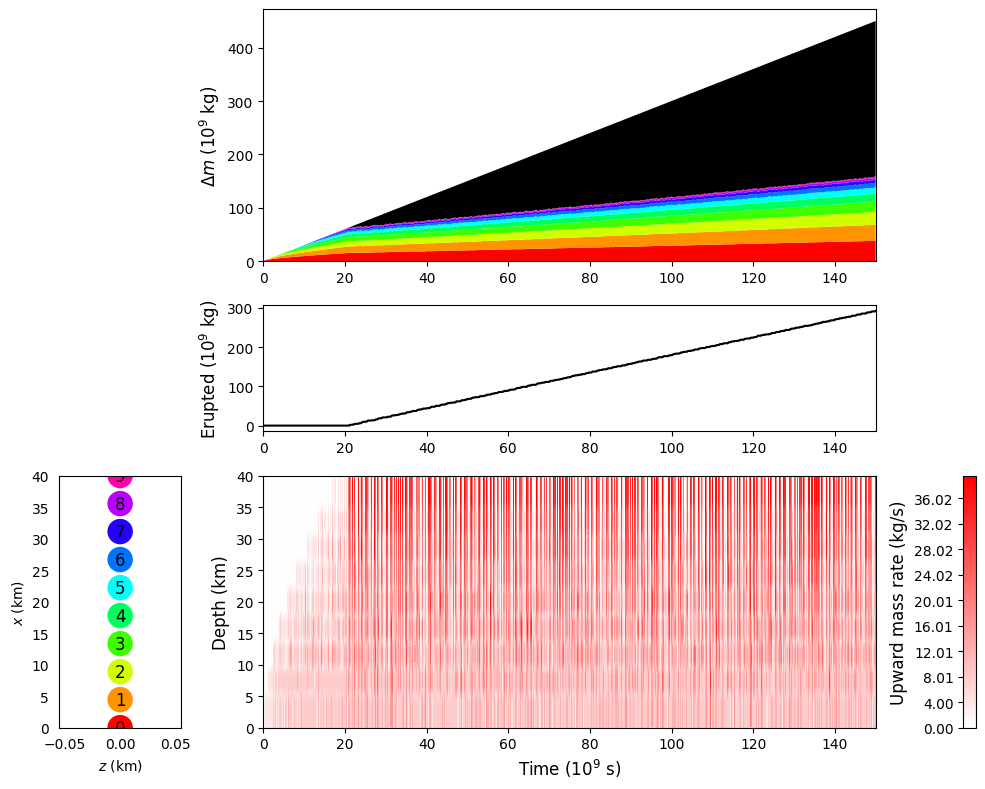

In [29]:
fig = plt.figure(figsize=(11,8), dpi=100)
gridspec = fig.add_gridspec(3, 3, width_ratios=[1, 5, 1],
    height_ratios=[2, 1, 2])
ax = [fig.add_subplot(gridspec[0,1]),
      fig.add_subplot(gridspec[1,1]),
      fig.add_subplot(gridspec[2,0]),
      fig.add_subplot(gridspec[2,1]),
      fig.add_subplot(gridspec[2,2]),]

# Delta mass, lifted to zero
include_erupted_mass = True
t_plot_scale = 1e9
m_plot_scale = 1e9
if include_erupted_mass:
  # Augment data with erupted mass time series
  m_bars_data = np.concatenate((m.T, m_erupted_out[np.newaxis,:]), axis=0)
  colors_aug = np.concatenate((colors, [[0,0,0,1]]), axis=0)
  polys = ax[0].stackplot(t_vec/t_plot_scale,
                          (m_bars_data - m_bars_data.min(axis=1, keepdims=True))/m_plot_scale,
                          colors=colors_aug)
else:
  polys = ax[0].stackplot(t_vec/t_plot_scale,
                          (m.T - m.T.min(axis=1, keepdims=True))/m_plot_scale,
                          colors=colors)
ax[0].set_ylabel("$\Delta m$ ($10^9$ kg)", fontsize=12)
ax[0].set_xlim(t_vec[0]/1e9, t_vec[-1]/1e9)

# Total mass erupted plot
ax[1].plot(t_vec/t_plot_scale, m_erupted_out/m_plot_scale, 'k')
ax[1].set_ylabel("Erupted ($10^9$ kg)", fontsize=12)
ax[1].set_xlim(t_vec[0]/1e9, t_vec[-1]/1e9)

# Adjust clim for mass rate plot
clim = (mdot_grid.min(), mdot_grid.max(),)
shift_div_cmap = cnetwork.zero_aligned_cmap(clim)
if clim[1] - clim[0] ==0 :
  print("Data values are all zero. Skipping mass rate spatial plot.")

else:
  plt.sca(ax[3])

  mg_t, mg_z = np.meshgrid(t_vec, z_sample_mesh)
  plt.contourf(mg_t/1e9, mg_z/1e3, mdot_grid.T, cmap=shift_div_cmap, levels=np.linspace(clim[0], clim[1], 100))
  cb = plt.colorbar(ax=ax[4], location='left')#, ax=ax[:])
  ax[4].set_visible(False)
  cb.set_label("Upward mass rate (kg/s)", fontsize=12)
  plt.xlabel("Time ($10^9$ s)", fontsize=12)
  plt.ylabel("Depth (km)", fontsize=12)

  fig.tight_layout()

  print("Shown: mass transfer timescale")
  print(f"Deviatoric Maxwell time = {t_d:e} s")

  global_sys.show_network(q_out[0,:], ax=ax[2], node_scale=300)
  ax[2].set_ylim(0, z_scale/1e3)

fig.set_tight_layout(True)

In [ ]:
plot_graph_snapshots = False
if plot_graph_snapshots:
  t_select_index = 0

  fig, ax = plt.subplots(1, 4, figsize=(10,5), dpi=100)
  index_array = (t_vec.size * np.array([0.1, 0.3, 0.5, 0.9])).astype(int)
  for i, t_select_index in enumerate(index_array):
    global_sys.show_network(q_out[t_select_index,:], ax=ax[i], node_scale=300)
    print(f"Time index {t_select_index}. Chambers are in a 2D plane. ")
    ax[i].set_title(f"{t_vec[t_select_index]:.2e} s")
  fig.set_tight_layout(True)

''' Wall displacement, pressure in each chamber '''
plot_u_p_time_series = False
if plot_u_p_time_series:
  fig, ax = plt.subplots(1, 2, figsize=(7,5), dpi=100)
  cmap = matplotlib.cm.hsv
  colors = cmap(np.linspace(0,1,global_sys.num_blocks,endpoint=False))

  for i in range(p.shape[1]):
    ax[0].plot(t_vec, u[:,i,0], color=colors[i])
  ax[0].set_xlabel("$t$ (s)")
  ax[0].set_ylabel("$u$ (m)")

  for i in range(p.shape[1]):
    ax[1].semilogx(t_vec, p[:,i] / 1e6, color=colors[i])
  ax[1].set_xlabel("$t$ (s)")
  ax[1].set_ylabel("$p$ (MPa)")

  fig.tight_layout()